### Импорт библиотек

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Загружаем датасеты

In [2]:
sales = pd.read_csv('sales data-set.csv')
features = pd.read_csv('Features data set.csv')
stores = pd.read_csv('stores data-set.csv')

____

In [3]:
# размерность

print(sales.shape, features.shape, stores.shape)

(421570, 5) (8190, 12) (45, 3)


In [4]:
# смотрим типы данных в датасетах

print(sales.dtypes)

Store             int64
Dept              int64
Date                str
Weekly_Sales    float64
IsHoliday          bool
dtype: object


In [5]:
print(features.dtypes)

Store             int64
Date                str
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object


In [6]:
print(stores.dtypes)

Store    int64
Type       str
Size     int64
dtype: object


In [7]:
# сколько пропусков в датасетах

print(sales.isna().sum())
print("\n")
print(features.isna().sum())
print("\n")
print(stores.isna().sum())

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64


Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


Store    0
Type     0
Size     0
dtype: int64


In [8]:
# проверка на дубликаты

print(sales.duplicated().sum())
print("\n")
print(features.duplicated().sum())
print("\n")
print(stores.duplicated().sum())

0


0


0


In [9]:
# считаем, смотрим среднее, среднее, минимальное, квартили, макс

sales.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


в датасете sales есть отрицательные значения в weekly_sales - гипотеза (возвраты?)

In [10]:
features.describe()

,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
std,12.987966,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259
min,1.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000


в датасете features есть  markdown с отрицательными значениями: проверить, свести к нулю

In [11]:
stores.describe()

,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


In [12]:
# просто посмотрим как выглядят таблицы

sales.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False
5,1,1,12/03/2010,21043.39,False
6,1,1,19/03/2010,22136.64,False
7,1,1,26/03/2010,26229.21,False
8,1,1,02/04/2010,57258.43,False
9,1,1,09/04/2010,42960.91,False


In [13]:
features.head(10)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
5,1,12/03/2010,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False
6,1,19/03/2010,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,False
7,1,26/03/2010,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,False
8,1,02/04/2010,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,False
9,1,09/04/2010,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,False


у markdown есть NaN значения.... посмотреть распределённость проспусков

In [14]:
stores.head(10)

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


### Преобразование, нормализация

Преобразуем колонки Date в datetime

In [15]:
sales['Date'] = pd.to_datetime(sales['Date'], format='%d/%m/%Y')
features['Date'] = pd.to_datetime(features['Date'], format='%d/%m/%Y')

Преобразуем отрицательные значения в колонках со скидками Markdown в нулевые

In [16]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

In [17]:
for col in markdown_cols:
    features[col] = features[col].mask(features[col] < 0, 0)

In [18]:
# проверяем

features.describe()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,2011-10-31 12:00:00,59.356198,3.405992,7033.397205,3384.393567,1760.211982,3292.935886,4132.271284,172.460809,7.826821
min,1.000000,2010-02-05 00:00:00,-7.290000,2.472000,0.000000,0.000000,0.000000,0.220000,0.000000,126.064000,3.684000
25%,12.000000,2010-12-17 00:00:00,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,2011-10-31 12:00:00,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,2012-09-14 00:00:00,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,2013-07-26 00:00:00,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000
std,12.987966,NaN,18.678607,0.431337,9261.852799,8793.497335,11276.444212,6792.329861,13086.672614,39.738346,1.877259


Смотрим распределение NaN значений в Markdown колонках по отношению ко времени

In [19]:
features['Month'] = features['Date'].dt.to_period('M').dt.to_timestamp()

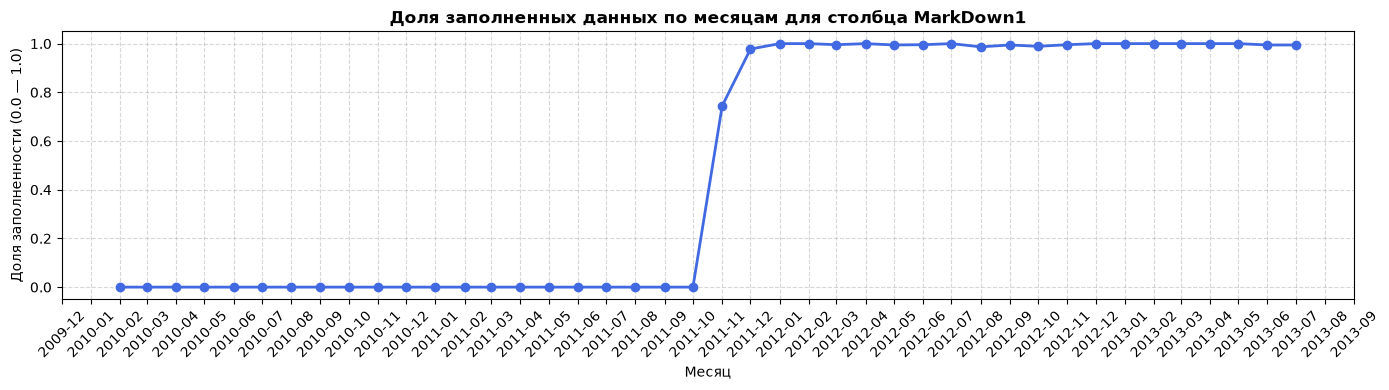

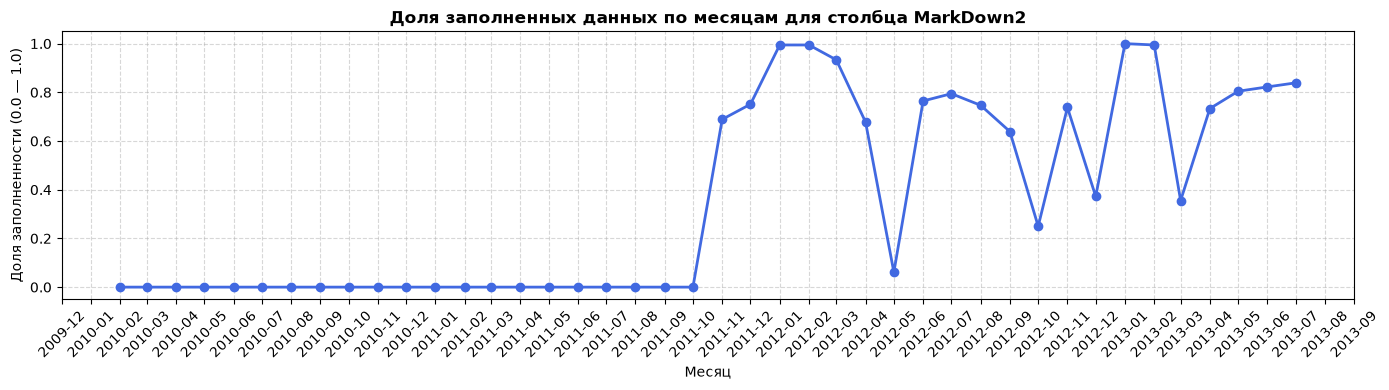

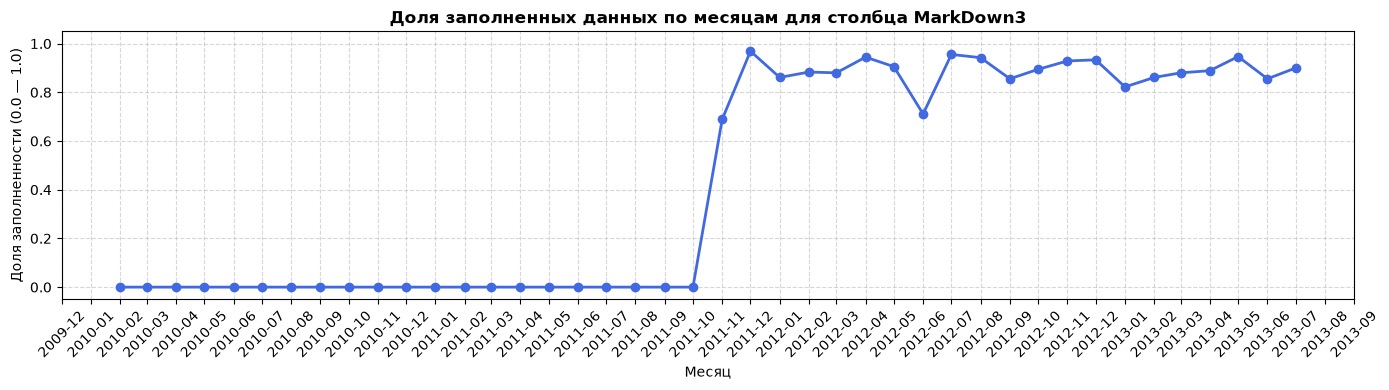

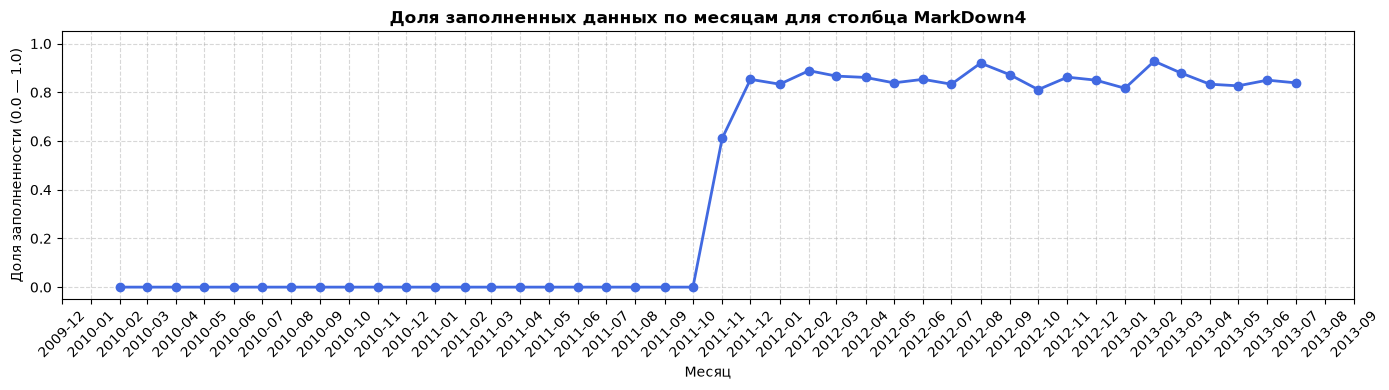

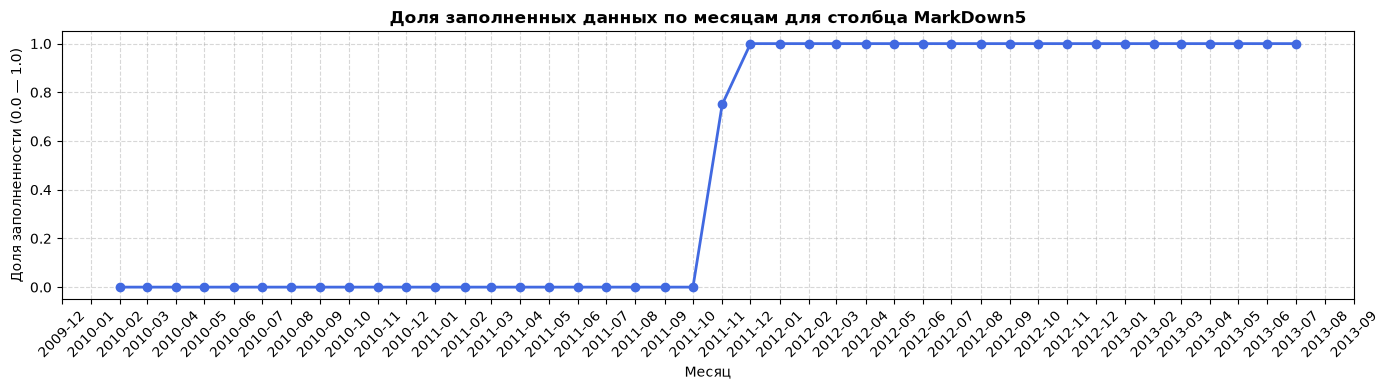

In [20]:
for col in markdown_cols:
    plt.figure(figsize=(14, 4))
    
    monthly_agg = features.groupby('Month')[col].agg(
        Total='size',
        Filled=lambda x: x.notna().sum()
    ).reset_index()
    
    monthly_agg['Ratio'] = monthly_agg['Filled'] / monthly_agg['Total']
    
    plt.plot(monthly_agg['Month'], monthly_agg['Ratio'], marker='o', linestyle='-', color='royalblue', linewidth=2)
    
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    
    plt.title(f'Доля заполненных данных по месяцам для столбца {col}', fontsize=12, fontweight='bold')
    plt.xlabel('Месяц', fontsize=10)
    plt.ylabel('Доля заполненности (0.0 — 1.0)', fontsize=10)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

Так, тут делать нечего, просто до ноября 2011 примем как факт, что данных нет.

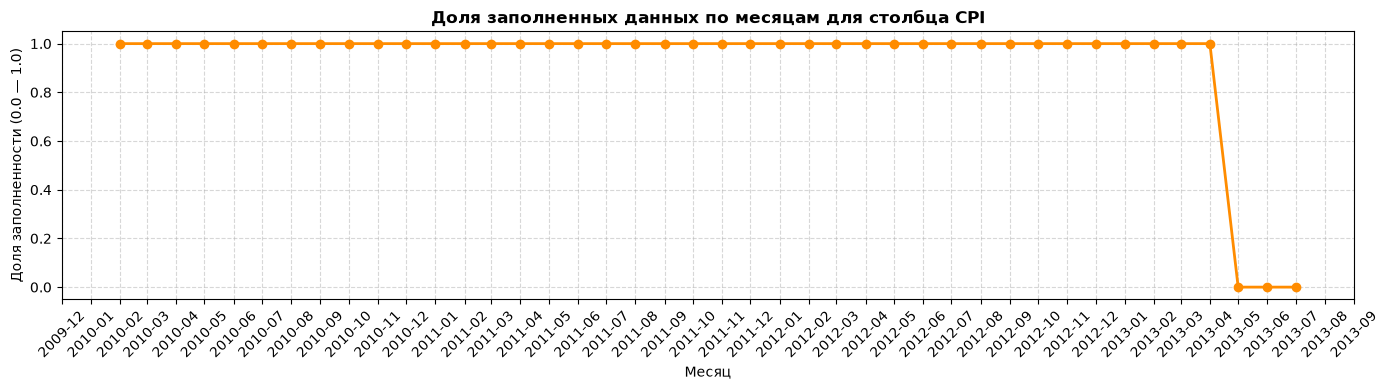

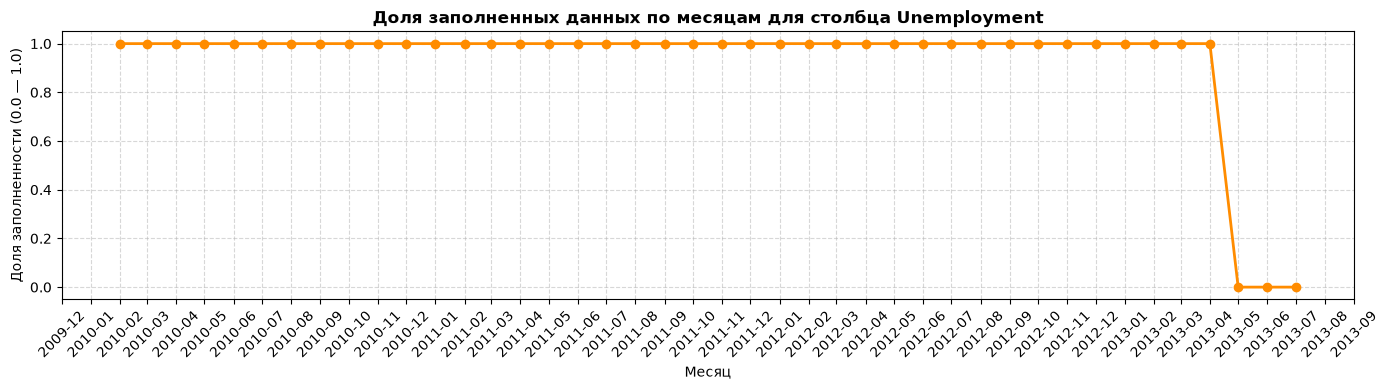

In [21]:
# посмотрим распределение данных по временному ряду для CPI и безработице

macro_cols = ['CPI', 'Unemployment']

for col in macro_cols:
    plt.figure(figsize=(14, 4))
    
    
    monthly_agg = features.groupby('Month')[col].agg(
        Total='size',
        Filled=lambda x: x.notna().sum()
    ).reset_index()
    
    monthly_agg['Ratio'] = monthly_agg['Filled'] / monthly_agg['Total']
    
    
    plt.plot(monthly_agg['Month'], monthly_agg['Ratio'], marker='o', linestyle='-', color='darkorange', linewidth=2)
    
    
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    
    plt.title(f'Доля заполненных данных по месяцам для столбца {col}', fontsize=12, fontweight='bold')
    plt.xlabel('Месяц', fontsize=10)
    plt.ylabel('Доля заполненности (0.0 — 1.0)', fontsize=10)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [22]:
# Итого

print(sales.shape, features.shape, stores.shape)

(421570, 5) (8190, 13) (45, 3)


Устранены нелогичные значения в полях, проверены дубликаты, а также унифицированы форматы дат для корректной работы с временными рядами.